# Pré-processamento de Dados

Neste notebook você vai aprender:

- Carregar dados e simular problemas reais (valores ausentes, classes desbalanceadas)
- Tratamento de valores ausentes (imputação)
- Escalonamento de features
- Codificação de variáveis categóricas
- Tratamento de desbalanceamento de classes
- Redução de dimensionalidade (PCA)
- Divisão dos dados (treino / validação / teste)

---


In [1]:
# Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    LabelEncoder, OneHotEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold
)
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)


## Dataset Iris

# <img src="https://miro.medium.com/v2/resize:fit:1100/format:webp/1*H2UmG5L1I5bzFCW006N5Ag.png" style="margin-top:-2cm; margin-bottom:0cm;">


![Iris Dataset - Distribuição das espécies](https://miro.medium.com/v2/resize:fit:720/format:webp/1*nfK3vGZkTa4GrO7yWpcS-Q.png)


O Iris é um clássico: 150 flores, 4 medidas numéricas e 3 espécies. Na prática, dados raramente chegam prontos. Então vamos carregar uma versão manipulada para simular problemas comuns.

In [2]:
df = pd.read_csv('Datasets/iris_manipulated.csv')

In [3]:
df.shape

(120, 5)

In [4]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,NaN,NaN,1.4,0.2,setosa
2,4.7,3.2,NaN,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,NaN,0.2,setosa


In [5]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [6]:
df['species'].value_counts()

species
versicolor    50
setosa        49
virginica     19
Name: count, dtype: int64

### Análise exploratória dos dados


In [7]:
df.isnull().sum()
# df.isna().sum()

sepal_length     9
sepal_width      8
petal_length    16
petal_width     16
species          2
dtype: int64

In [8]:
# Estatísticas das colunas numéricas (ignorando NaN)
df.describe()


,sepal_length,sepal_width,petal_length,petal_width
count,111.000000,112.000000,104.000000,104.000000
mean,5.663063,3.068750,3.383654,0.982692
std,0.757259,0.453024,1.695975,0.694422
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.500000,0.200000
50%,5.600000,3.000000,4.000000,1.150000
75%,6.150000,3.400000,4.700000,1.500000
max,7.700000,4.400000,6.900000,2.400000


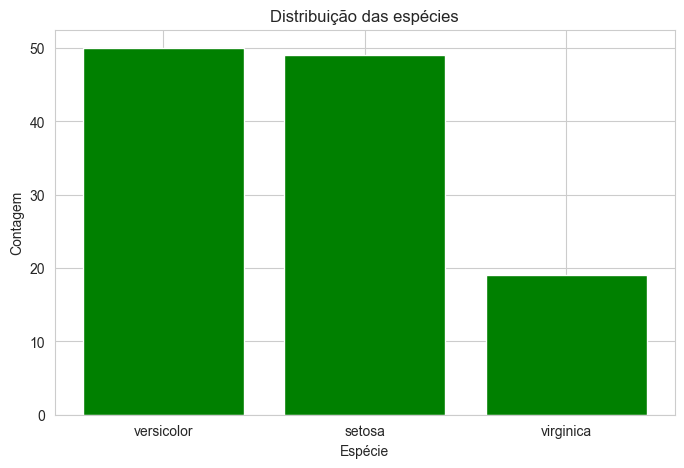

In [9]:
# plt.figure(figsize=(6,4))
species_counts = df['species'].value_counts()
plt.bar(species_counts.index, species_counts.values, color='green')
plt.title('Distribuição das espécies')
plt.xlabel('Espécie')
plt.ylabel('Contagem')
plt.show()


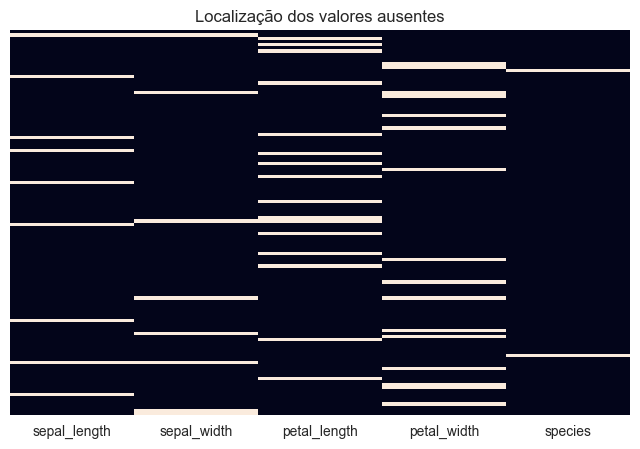

In [10]:
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title('Localização dos valores ausentes')
plt.show()


In [11]:
df.head(10)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,NaN,NaN,1.4,0.2,setosa
2,4.7,3.2,NaN,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,NaN,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,NaN,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


## Imputação de valores ausentes

Quando um valor está ausente (`NaN`), temos três estratégias clássicas de **imputação**:

| Estratégia | Quando usar | Exemplo |
|------------|-------------|---------|
| **Média** | Dados simétricos, sem outliers | `sepal_length` |
| **Mediana** | Dados com outliers | `petal_length` |
| **Moda** | Valor mais frequente | `petal_width` |

In [12]:
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

# Sem rótulo (species ausente) não dá para treinar — removemos essas linhas
df_work = df.dropna(subset=['species']).reset_index(drop=True)

# Quantas linhas foram excluídas após o dropna de 'species'?
num_excluidas = df.shape[0] - df_work.shape[0]
print(f"Linhas excluídas por ausência da coluna 'species': {num_excluidas}")

X_num = df_work[features]
y = df_work['species']

print("Ausentes antes da imputação:")
print(X_num.isnull().sum())

Linhas excluídas por ausência da coluna 'species': 2
Ausentes antes da imputação:
sepal_length     9
sepal_width      8
petal_length    16
petal_width     16
dtype: int64


### Imputação pela média

In [13]:
X_num.head(5)

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,NaN,NaN,1.4,0.2
2,4.7,3.2,NaN,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,NaN,0.2


In [14]:
imputer_mean = SimpleImputer(strategy='mean')

X_mean = pd.DataFrame(imputer_mean.fit_transform(X_num), columns=X_num.columns)

X_mean.head()


,sepal_length,sepal_width,petal_length,petal_width
0,5.100000,3.50,1.400000,0.2
1,5.657798,3.07,1.400000,0.2
2,4.700000,3.20,3.378431,0.2
3,4.600000,3.10,1.500000,0.2
4,5.000000,3.60,3.378431,0.2


### Imputação pela mediana

In [15]:
imputer_median = SimpleImputer(strategy='median')
X_median = pd.DataFrame(
    imputer_median.fit_transform(X_num),
    columns=X_num.columns
)

X_median.head()


,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,5.6,3.0,1.4,0.2
2,4.7,3.2,4.0,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,4.0,0.2


### Imputação pela Moda

In [16]:
imputer_mode = SimpleImputer(strategy='most_frequent')
X_mode = pd.DataFrame( imputer_mode.fit_transform(X_num), columns=X_num.columns)

X_mode.head()


,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,5.0,3.0,1.4,0.2
2,4.7,3.2,1.5,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.5,0.2


> A Moda também funciona para variáveis numéricos, mas é mais usada em categóricas

---
## Escalonamento

In [17]:
df_iris = pd.read_csv('Datasets/iris.csv')
df_iris = df_iris.drop(columns=['Species'])
df_iris.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


As features do Iris têm **escalas diferentes** (ex.: `sepal_length` ~ 4–8, `petal_width` ~ 0–2). Algoritmos como KNN, SVM e PCA são sensíveis a isso, por essa razão, escalamos as features.

| Técnica | O que faz |
|---------|-----------|
| **StandardScaler** | Média = 0, desvio = 1 |
| **MinMaxScaler** | Valores entre 0 e 1 |
| **RobustScaler** | Usa mediana e IQR (robusto a outliers) |

### Dados sem escalonamento

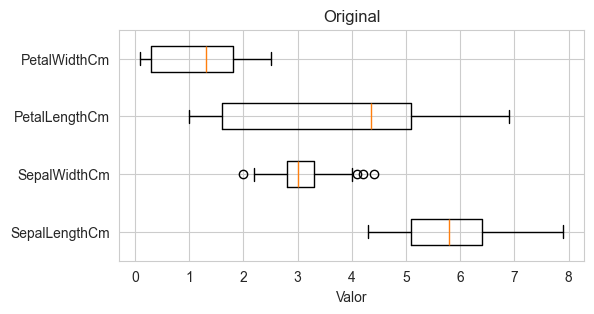

In [18]:
plt.figure(figsize=(6, 3))
plt.boxplot(df_iris.values, labels=df_iris.columns, vert=False)
plt.title('Original')
plt.xlabel('Valor')
plt.show()

### StandardScaler

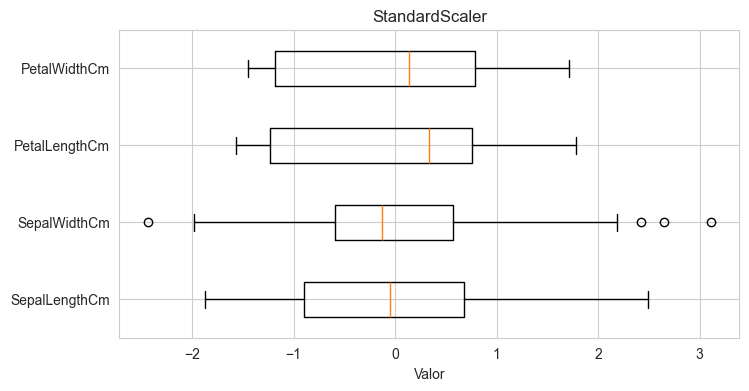

In [19]:
data = pd.DataFrame(StandardScaler().fit_transform(df_iris), columns=df_iris.columns)
plt.figure(figsize=(8, 4))
plt.boxplot(data.values, labels=data.columns, vert=False)
plt.title('StandardScaler')
plt.xlabel('Valor')
plt.show()

### MinMax Scaler

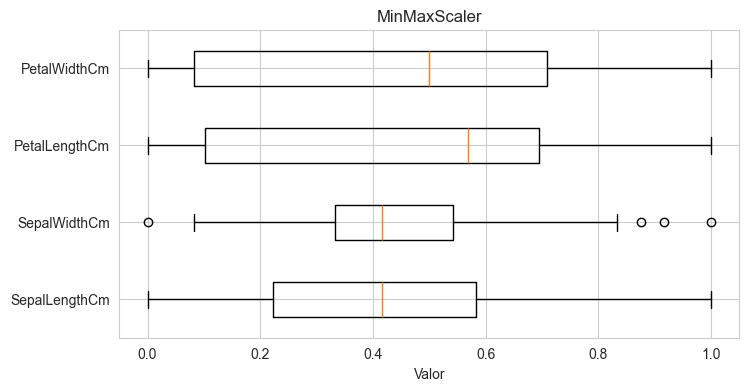

In [20]:
data = pd.DataFrame(MinMaxScaler().fit_transform(df_iris), columns=df_iris.columns)
plt.figure(figsize=(8, 4))
plt.boxplot(data.values, labels=data.columns, vert=False)
plt.title('MinMaxScaler')
plt.xlabel('Valor')
plt.show()

### RobustScaler

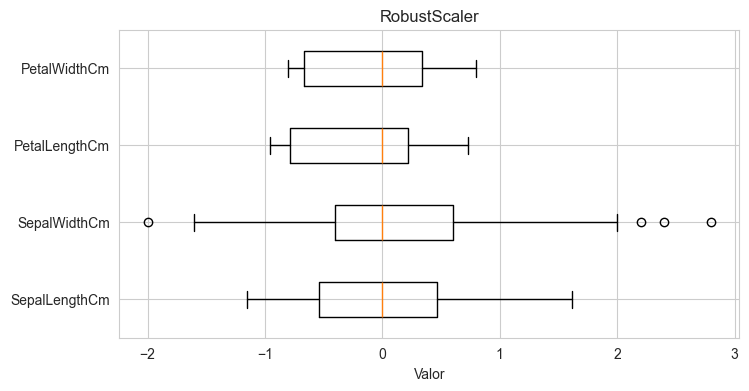

In [21]:
data = pd.DataFrame(RobustScaler().fit_transform(df_iris), columns=df_iris.columns)
plt.figure(figsize=(8, 4))
plt.boxplot(data.values, labels=data.columns, vert=False)
plt.title('RobustScaler')
plt.xlabel('Valor')
plt.show()

---

## Codificação de variáveis categóricas

A coluna `species` do Iris contém texto. Vamos aplicar duas abordagens para convertê-las em números:

- **LabelEncoder** : Atribui 0, 1, 2...; Ideal para variável ordinal.
- **OneHotEncoder** : Cria colunas binárias (0/1). Ideal para variáveis nominais sem ordem.

> **Cuidado:** LabelEncoder em features categóricas pode induzir uma ordem que não existe. Para features, prefira OneHotEncoder.


In [22]:
df_iris = pd.read_csv('Datasets/iris.csv')
y = df_iris['Species']
x = df_iris.drop(columns=['Species'])
# x.head()

In [23]:
le = LabelEncoder()
y_le = le.fit_transform(y)
print(le.classes_)
# Mostra os 5 primeiros valores da coluna 'Species' codificados numericamente pelo LabelEncoder
print(y_le[:5])


['setosa' 'versicolor' 'virginica']
[0 0 0 0 0]


In [24]:
ohe = OneHotEncoder(sparse_output=False)
y_ohe = ohe.fit_transform(y.values.reshape(-1, 1))  # reshape pq OneHotEncoder espera uma matriz 2D
print(y_ohe[:5])

[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


---
## Desbalanceamento de classes

Quando uma classe tem muito mais exemplos que outra, o modelo tende a **ignorar a classe minoritária**. O Iris original é **balanceado** (50 amostras por classe). Para visualizar o efeito do desbalanceamento, usaremos o dataset **Abalone**.

In [25]:
df_ab = pd.read_csv('Datasets/abalone.csv')
df_ab.head()

,Rings,Sex,Length,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight
0,15,0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150
1,7,0,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070
2,9,1,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210
3,10,0,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155
4,7,2,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055


In [26]:
df_ab.describe()

,Rings,Sex,Length,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,9.933684,0.955470,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831
std,3.224169,0.827815,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203
min,1.000000,0.000000,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500
25%,8.000000,0.000000,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000
50%,9.000000,1.000000,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000
75%,11.000000,2.000000,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000
max,29.000000,2.000000,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000


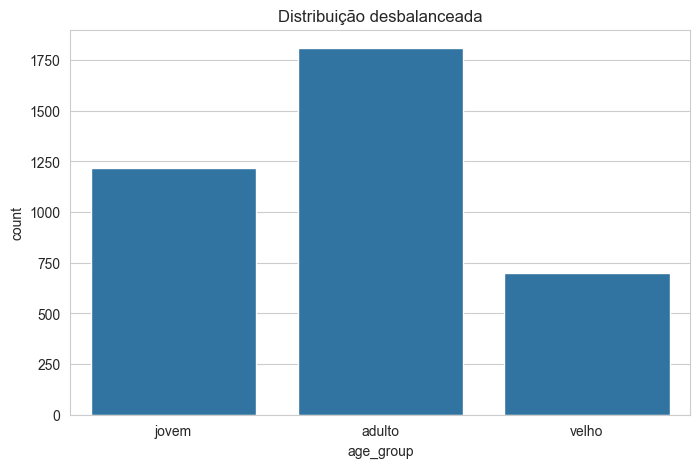

In [27]:
df_ab = df_ab[(df_ab['Rings'] > 5) & (df_ab['Rings'] < 16)]

# Agrupei em poucas classes para facilitar a visualização
df_ab['age_group'] = pd.cut(df_ab['Rings'], bins=[5, 8, 11, 16], labels=['jovem', 'adulto', 'velho'])

sns.countplot(data=df_ab, x='age_group')
plt.title('Distribuição desbalanceada')
plt.show()

In [28]:
X = df_ab[['Length', 'Diameter', 'Height', 'WholeWeight', 'ShuckedWeight', 'VisceraWeight', 'ShellWeight']]
y = df_ab['age_group']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=None, random_state=42)

print("Treino — antes do balanceamento:")
print(y_train.value_counts())

print("Teste — depois do balanceamento:")
print(y_test.value_counts())


Treino — antes do balanceamento:
age_group
adulto    1298
jovem      835
velho      475
Name: count, dtype: int64
Teste — depois do balanceamento:
age_group
adulto    512
jovem     383
velho     224
Name: count, dtype: int64


### Modelo sem balanceamento

In [29]:
model_base = KNeighborsClassifier(n_neighbors=5)
model_base.fit(X_train, y_train)
y_pred_base = model_base.predict(X_test)
print(classification_report(y_test, y_pred_base))


              precision    recall  f1-score   support

      adulto       0.59      0.74      0.65       512
       jovem       0.72      0.71      0.71       383
       velho       0.48      0.21      0.29       224

    accuracy                           0.62      1119
   macro avg       0.60      0.55      0.55      1119
weighted avg       0.61      0.62      0.60      1119



### Oversampling

In [30]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler()
X_over, y_over = ros.fit_resample(X_train, y_train)
print(y_over.value_counts())


age_group
jovem     1298
adulto    1298
velho     1298
Name: count, dtype: int64


### SMOTE

In [31]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)
print(y_smote.value_counts())


age_group
jovem     1298
adulto    1298
velho     1298
Name: count, dtype: int64


### Undersampling

In [32]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler()
X_under, y_under = rus.fit_resample(X_train, y_train)
print(y_under.value_counts())


age_group
jovem     475
adulto    475
velho     475
Name: count, dtype: int64


In [33]:
# Comparando os métodos de balanceamento de forma simples
metodos = {
    'Oversampling': (X_over, y_over),
    'Undersampling': (X_under, y_under),
    'SMOTE': (X_smote, y_smote)
}

for nome, (Xb, yb) in metodos.items():
    modelo = KNeighborsClassifier()
    modelo.fit(Xb, yb)
    y_pred = modelo.predict(X_test)
    print(f"\n{nome.upper()}")
    print(classification_report(y_test, y_pred))



OVERSAMPLING
              precision    recall  f1-score   support

      adulto       0.61      0.49      0.54       512
       jovem       0.66      0.74      0.70       383
       velho       0.38      0.48      0.42       224

    accuracy                           0.57      1119
   macro avg       0.55      0.57      0.56      1119
weighted avg       0.58      0.57      0.57      1119


UNDERSAMPLING
              precision    recall  f1-score   support

      adulto       0.62      0.54      0.58       512
       jovem       0.68      0.75      0.71       383
       velho       0.45      0.51      0.48       224

    accuracy                           0.61      1119
   macro avg       0.58      0.60      0.59      1119
weighted avg       0.61      0.61      0.60      1119


SMOTE
              precision    recall  f1-score   support

      adulto       0.60      0.47      0.53       512
       jovem       0.66      0.75      0.70       383
       velho       0.39      0.49      

![PCA Pipeline](https://miro.medium.com/v2/1*7xf9e1EaoK5n05izIFBouA.png)

---
## Redução de dimensionalidade


A **Análise de Componentes Principais (PCA)** projeta os dados em um espaço de menor dimensão.

> O PCA é sensível à variância de cada feature, então é preciso aplicar scaling antes.

In [34]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)
# print(X_pca)

In [35]:
print(f"Variância explicada por cada componente principal: {pca.explained_variance_ratio_.round(3)}")
#Esses valores mostram a proporção da variância total dos dados que é explicada por cada componente principal,
# ou seja, quanto da informação original se mantém em cada dimensão reduzida.
print(f"Variância explicada total pelos 2 componentes: {pca.explained_variance_ratio_.sum():.3f}")


Variância explicada por cada componente principal: [0.906 0.045 0.023]
Variância explicada total pelos 2 componentes: 0.973


In [36]:
print(X_pca)

[[-1.98543107 -0.53323893  0.15555351]
 [-3.73061629 -0.10964443 -0.44856203]
 [-0.6094013   0.12370905  0.48383609]
 ...
 [ 2.1998947   0.9200299  -0.28544691]
 [ 1.66352325 -0.3543265   0.20580877]
 [ 5.11938976 -0.47498807 -0.67090654]]


---
## Data Splitting

Antes de treinar um modelo, separamos os dados em conjuntos:

- **Treino:** usado para o modelo aprender.
- **Validação:** usado para comparar opções (ex.: escolher hiperparâmetros).
- **Teste:** usado **uma única vez** no final, para medir desempenho real.

A função `train_test_split` do scikit-learn faz essa separação de forma aleatória.

| Parâmetro | O que faz |
|-----------|-----------|
| `test_size=0.3` | 30% vão para teste, 70% para treino |
| `random_state=42` | Fixa a aleatoriedade (resultado reproduzível) |
| `stratify=y` | Mantém a proporção das classes em cada conjunto |



In [37]:
df_iris = pd.read_csv('Datasets/iris.csv')

feature_cols = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
X = df_iris[feature_cols].values
y = df_iris['Species'].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Escalonamento (recomendado para KNN)
X = StandardScaler().fit_transform(X)

print(x)
print(y_encoded)


     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0              5.1           3.5            1.4           0.2
1              4.9           3.0            1.4           0.2
2              4.7           3.2            1.3           0.2
3              4.6           3.1            1.5           0.2
4              5.0           3.6            1.4           0.2
..             ...           ...            ...           ...
145            6.7           3.0            5.2           2.3
146            6.3           2.5            5.0           1.9
147            6.5           3.0            5.2           2.0
148            6.2           3.4            5.4           2.3
149            5.9           3.0            5.1           1.8

[150 rows x 4 columns]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 


<img src="https://cdn.builtin.com/cdn-cgi/image/f=auto/sites/www.builtin.com/files/styles/ckeditor_optimize/public/inline-images/1_train-test-split_0.jpg" alt="train-test split illustration"/>

In [38]:
# Divisão em treino / validação / teste (60% / 20% / 20%)

# 1º passo: reserva 20% para teste
X_treino_validacao, X_teste, y_treino_validacao, y_teste = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

# 2º passo: dos 80% restantes, reserva 25% para validação (= 20% do total)
X_treino, X_validacao, y_treino, y_validacao = train_test_split(
    X_treino_validacao, y_treino_validacao, test_size=0.2, stratify=y_treino_validacao, random_state=42
)

n_amostras = len(X)
print(f"  Treino:    {len(X_treino):3d} amostras ({len(X_treino)/n_amostras*100:.0f}%)")
print(f"  Validação: {len(X_validacao):3d} amostras ({len(X_validacao)/n_amostras*100:.0f}%)")
print(f"  Teste:     {len(X_teste):3d} amostras ({len(X_teste)/n_amostras*100:.0f}%)")

modelo = KNeighborsClassifier(n_neighbors=5)
modelo.fit(X_treino, y_treino)
print(f"\nAcurácia na validação: {modelo.score(X_validacao, y_validacao):.3f}")
print(f"Acurácia no teste:     {modelo.score(X_teste, y_teste):.3f}")


  Treino:     96 amostras (64%)
  Validação:  24 amostras (16%)
  Teste:      30 amostras (20%)

Acurácia na validação: 0.958
Acurácia no teste:     0.967


---
## Validação cruzada (k-fold)

Em uma situação onde temos poucos dados, separar em treino e teste pode gerar resultados instáveis devido à variabilidade da amostra. Para obter uma avaliação mais confiável do desempenho do modelo, utiliza-se a **validação cruzada k-fold**. O modelo é treinado *k* vezes, cada vez utilizando *k−1* folds para treino e o fold restante para teste. No final, calcula-se a **média** das métricas obtidas em cada rodada.

# <img src="https://towardsdatascience.com/wp-content/uploads/2023/12/1N45hocCMP0u4nXLe0WuSvw.png" alt="k-fold illustration"/>

Existem diferentes tipos de k-fold. O método padrão divide os dados aleatoriamente, mas pode resultar em desequilíbrio das classes entre os folds. O **StratifiedKFold** é uma variante que garante que cada fold tenha uma proporção de classes similar à do conjunto original, evitando que uma ou mais classes fiquem sub-representadas em algum fold.

O `cross_val_score` é uma função do scikit-learn utilizada para avaliar o desempenho de um modelo por meio da validação cruzada. Em vez de simplesmente dividir o conjunto de dados em treino e teste apenas uma vez, o `cross_val_score` realiza múltiplas divisões dos dados, treinando e avaliando o modelo várias vezes, cada vez em uma partição diferente dos dados.

In [39]:
scores = cross_val_score(
    KNeighborsClassifier(n_neighbors=5),
    X, y_encoded,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy'
)

print(f"Acurácias por fold: {scores.round(3)}")
print(f"Média: {scores.mean():.3f} (+/- {scores.std():.3f})")

Acurácias por fold: [1.    0.967 0.9   1.    0.967]
Média: 0.967 (+/- 0.037)


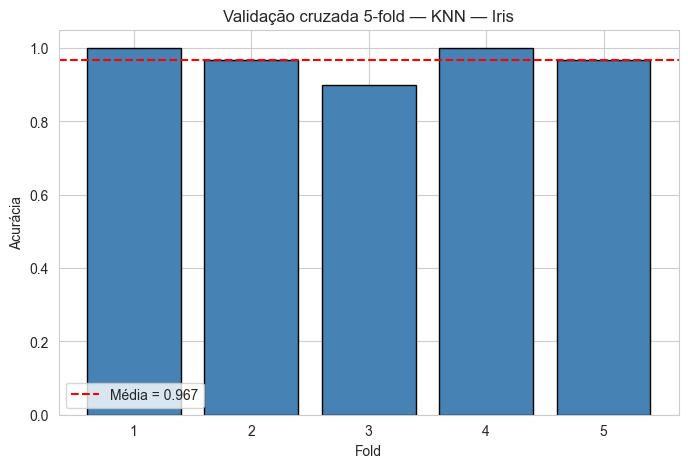

In [40]:
plt.bar(range(1, 6), scores, color='steelblue', edgecolor='black')
plt.axhline(scores.mean(), color='red', linestyle='--', label=f'Média = {scores.mean():.3f}')
plt.xlabel('Fold')
plt.ylabel('Acurácia')
plt.title('Validação cruzada 5-fold — KNN — Iris')
plt.legend()
plt.show()